In [114]:
using CairoMakie
using MAGEMin_C
using CSV
using DataFrames
using JLD2
using Accessors

# Load local modules explicitly each time Cell 1 is run.
# This avoids notebook state issues and makes modules available to later cells.
include("Modules/LatticeStrainModels.jl")
include("Modules/LSMUtils.jl")
include("Modules/PartitionCoefficients.jl")
include("Modules/LSMPlotting.jl")

import .LatticeStrainModels
import .LSMUtils
import .PartitionCoefficients
import .LSMPlotting

1) Define initial bulk composition

In [115]:
""" Major element composition """
oxides = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "K2O"; "Na2O"; "TiO2"; "O"; "Cr2O3"; "H2O"]
# oxides = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "Fe2O3"; "K2O"; "Na2O"; "TiO2"; "Cr2O3"; "H2O"]

sys_in = "wt"

# CHANGE THIS TO ANY INPUT; ORDER NEEDS TO MATCH LIST OF OXIDES


# Blatter et al., 2013 (01SB-872)
bulk_0 = [49.90, 17.00, 10.05, 8.715, 9.235, 0.495, 3.045, 1.255, 0.0, 0.0, 0.0] # Blatter et al. (2013) 01SB-872 anhydrous

bulk_0 = bulk_0 ./ sum(bulk_0) .* 100.0

bulk_0[11] = h2o = 4.0

# Saturate in O for buffering
bulk_0[9] = 2.0

bulk_0[1:8] .*= (1.0-h2o/100.0)
println(bulk_0)

"""
# La Higuera Giovanini
bulk_0 = [39.03660573717069, 12.608627372069673, 6.5520942023632704, 23.977380474197837, 13.079029645618023, 0.0165187010885623, 0.4469766176905092, 0.02429220748317985, 2.0, 0.008847705847309916, 4.0]
"""

""" TE composition """

elements = [:La, :Ce, :Pr, :Nd, :Sm, :Eu, :Gd, :Tb, :Dy, :Ho, :Er, :Tm, :Yb, :Lu, :Sr, :Y]

charges = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3]

# CHANGE THIS TO ANY INPUT; ORDER NEEDS TO MATCH LIST OF ELEMENTS
TE_0 = [22.9, 49.4, 7.5, 25.4, 5.2, 1.6, 4.6, 0.6, 3.8, 0.71, 2., 0.28, 1.7, 0.26, 999.0, 20.4]

[48.05055419028035, 16.369928281257835, 9.677516425096544, 8.391995586538943, 8.892722804553888, 0.4766537940719193, 2.9321430362605945, 1.2084858819399165, 2.0, 0.0, 4.0]


16-element Vector{Float64}:
  22.9
  49.4
   7.5
  25.4
   5.2
   1.6
   4.6
   0.6
   3.8
   0.71
   2.0
   0.28
   1.7
   0.26
 999.0
  20.4

2) Define saturation models

In [116]:

# For zircon and apatite saturation models
sat_elements = ["Zr", "P2O5"]
#sat_phases = ["zrc", "fapt"]
sat_phases = ["cpx", "pig", "Na-cpx", "opx", "pl", "afs", "amp", "gl", "act", "cumm", "tr", "bi", "g", "ilm", "hem", "ep", "ru", "spl", "cm", "usp", "mgt", "zr", "ap"]
# Fixed Kds from Bédard 2006; DOI:10.1016/j.gca.2005.11.008
sat_Kds = [ "0.125" "0.162";
            "0.125" "0.162";
            "0.125" "0.162";
            "0.031" "0.050";
            "0.078" "0.079";
            "0.078" "0.079";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.417" "0.225";
            "0.023" "0.005";
            "0.537" "0.184";
            "2.3" "0.002";
            "2.3" "0.002";
            "0.10" "0.18";
            "3.7" "0.03";
            "0.12" "0.024";
            "0.12" "0.024";
            "0.12" "0.024";
            "0.12" "0.024";
            "0.0" "20.0";
            "16.0" "0.0"]

sat_C0s = [100.0, 0.07e4]

sat_KdsDB = create_custom_KDs_database(sat_elements, sat_phases, sat_Kds)

sat_models = ["CB", "Klein26"]

2-element Vector{String}:
 "CB"
 "Klein26"

3) Define pressure-temperature(-oxygen fugacity) conditions or path

In [117]:
# 4) Define P-T(-fO2) path of differentitation

T = collect(1200.0:-5.0:600.0)

nsteps = length(T)

pressure = 4.0

P = ones(nsteps)*pressure

buffer = "qfm"
# If a buffer ofset is to be used
boff = zeros(nsteps)

121-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

4.1) Option 1: Equilibrium crystallisation

In [ ]:
# Initalize MAGEMin
data = Initialize_MAGEMin("ig", buffer=buffer, verbose=false)


# Initialize melt frection
meltF = 1.0
# Initialize counter
np = 0


# Initialize output storage
Out_XY = Vector{out_struct}(undef, nsteps)
Out_Sat = Vector{out_TE_struct}(undef, nsteps)


# Out_TE should be a vector of dictionaries, where each dictionary corresponds to a step. Each step-dictionary is to be structured like Dict("phase" => Dict(:element => value))
Out_TE = Vector{Dict{String, Dict{Symbol, Float64}}}(undef, nsteps)


# Similar to Out_TE 
Out_Ds = Vector{Dict{String, Dict{Symbol, Float64}}}(undef, nsteps)

Out_EuR = zeros(Float64, nsteps)

param_dicts = [Dict{Symbol, Float64}() for _ in 1:nsteps]

while meltF > 0.0 && np <= nsteps

    np+=1
	
    # Reset initial bulk composition -> No melt sequestration
	bulk = deepcopy(bulk_0)
	sys_in = "wt"

    Out_TE[np] = Dict{String, Dict{Symbol, Float64}}()
    Out_Ds[np] = Dict{String, Dict{Symbol, Float64}}()

    # If input bulk composition is in wt.%, convert to mol.%
    if sys_in == "wt"
            bulk, _  = convertBulk4MAGEMin(bulk, oxides,"wt","ig"); sys_in = "mol"
    end

    # Routine from https://computationalthermodynamics.github.io/MAGEMin_C.jl/dev/MAGEMin_C/saturation_models#E.4-Saturation-models-and-bulk-correction
    tol     = 1e-6
    res     = 1.0
    n0      = 0.0
    ite     = 0

    while res > tol && ite < 32
        #println(bulk)
        out = single_point_minimization(P[np], T[np], data, X=bulk, Xoxides=oxides, B=boff[np], sys_in=sys_in, name_solvus=true);
        Out_XY[np] = deepcopy(out) # Store output
        #Finalize_MAGEMin(data)
        #pkbar = out.P_kbar
        SiO2wt = out.bulk_M[1] / (sum(out.bulk_M[1:end-1])) * 100.0
        """
            Temprary fix for not being able to access bulk composition -> Carry as P_kbar
            -> CB model needs to access out.P_kbar!!! So this yields somehat wrong saturation curves
        """
        #out = @set out.P_kbar = SiO2wt # THIS IS DANGEROUS, MIGHT BREAK THINGS!
        Out_Sat[np] = TE_prediction(out, sat_C0s, sat_KdsDB, "ig";
            ZrSat_model="CB",
            P2O5Sat_model="Klein26")


        # Reset P_kbar 
        #out = @set out.P_kbar = pkbar
        bulk .-= Out_Sat[np].bulk_cor_mol
        res = abs(n0 - vec_norm(Out_Sat[np].bulk_cor_mol))
        n0 = vec_norm(Out_Sat[np].bulk_cor_mol)

        ite += 1
        if ite == 32
            @warn "Saturation model did not converge in 32 iterations, residual is $res"
        end

    end

    out = Out_XY[np] # Get the output of the single point minimization for this step

    out_sat = Out_Sat[np] # Get the output of the saturation model for this step

    # Reset oxides
    if np==1
        oxides = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "K2O"; "Na2O"; "TiO2"; "O"; "Cr2O3"; "H2O"]
    end

	
    # If any of the entries in bulk are NaN, set them to the original value from bulk_0
    for i in eachindex(bulk)
        if isnan(bulk[i])
            bulk[i] = bulk_0[i]
        else
            # Nothing to do
        end
    end


    meltF = out.frac_M
    println("Step $np: Melt Fraction = $meltF")
    meltF_wt = out.frac_M_wt

    outte = Dict{String, Dict{Symbol, Float64}}()
    out_d = Dict{String, Dict{Symbol, Float64}}()

    phases = out.ph

    for phase in phases
        params = LSMUtils.get_params_for_phase(phase, out, out_sat, T[np], P[np])
        # Skip buffer and melt
        if phase in ["liq", buffer]
            out_d[phase] = Dict(el => 0.0 for el in elements)
        else
            Dphase = PartitionCoefficientsV2.get_D(phase, elements, charges, params)
            out_d[phase] = Dphase
            Out_TE[np][phase] = Dict(el => TE_0[i] * Dphase[el] for (i, el) in enumerate(elements))
        end
    end

    params = LSMUtils.get_params_for_phase("liq", out, out_sat, T[np], P[np])

    Out_EuR[np] = LSMUtils.Eu_ratio_Burnham(params[:logfO2], params[:T], params[:Λ])

    phase_fracs_wt = out.ph_frac_wt

    # Need to normalize phase_fracs_wt to 1 while omitting "liq" and "buffer" fractions, it can be done for all fractions as "liq" and "buffer" have zero Kds and thus do not contribute to the sum
    if "liq" in phases && buffer in phases
        phase_fracs_wt_used = phase_fracs_wt ./ (1.0 - phase_fracs_wt[findfirst(==(buffer), phases)] - phase_fracs_wt[findfirst(==("liq"), phases)])
    else
        phase_fracs_wt_used = phase_fracs_wt ./ sum(phase_fracs_wt)
    end

    Kd = Dict(el => sum((phase_fracs_wt_used[i] * get(out_d[phases[i]], el, 0.0) for i in eachindex(phases)); init=0.0) for el in elements)

    # Add Kd to out_d with key "bulk"
    out_d["bulk"] = Kd

    Out_Ds[np] = out_d

    Out_TE[np]["liq"] = Dict(el => TE_0[i] / (Kd[el] + meltF_wt * (1.0 - Kd[el])) for (i, el) in enumerate(elements))

end

Step 1: Melt Fraction = 1.0
Step 2: Melt Fraction = 1.0
Step 3: Melt Fraction = 1.0
Step 4: Melt Fraction = 1.0
Step 5: Melt Fraction = 1.0
Step 6: Melt Fraction = 1.0
Step 7: Melt Fraction = 1.0
Step 8: Melt Fraction = 1.0
Step 9: Melt Fraction = 1.0
Step 10: Melt Fraction = 1.0
Step 11: Melt Fraction = 1.0
Step 12: Melt Fraction = 1.0
Step 13: Melt Fraction = 1.0
Step 14: Melt Fraction = 1.0
Step 15: Melt Fraction = 1.0
Step 16: Melt Fraction = 1.0
Step 17: Melt Fraction = 1.0
Step 18: Melt Fraction = 1.0
Step 19: Melt Fraction = 1.0
Step 20: Melt Fraction = 1.0
Step 21: Melt Fraction = 1.0
Step 22: Melt Fraction = 1.0
Step 23: Melt Fraction = 0.9961233857107548
Step 24: Melt Fraction = 0.9918808427571562
Step 25: Melt Fraction = 0.9876505604248573
Step 26: Melt Fraction = 0.9747243720906511
Step 27: Melt Fraction = 0.9618585790253155
Step 28: Melt Fraction = 0.9492549857718706
Step 29: Melt Fraction = 0.936885658374779
Step 30: Melt Fraction = 0.9247451801570358
Step 31: Melt Fracti

4.2) Option 2: Fractional crystallisation

In [ ]:
# Initalize MAGEMin
data = Initialize_MAGEMin("ig", buffer=buffer, verbose=false)


# Initialize melt frection
meltF = 1.0
# Initialize counter
np = 0


# Initialize output storage
Out_XY = Vector{out_struct}(undef, nsteps)
Out_Sat = Vector{out_TE_struct}(undef, nsteps)

#Out_TE = [Dict{String, Vector{Float64}}() for _ in 1:nsteps]
# Out_TE should be a vector of dictionaries, where each dictionary corresponds to a step. Each step-dictionary is to be structured like Dict("phase" => Dict(:element => value))
Out_TE = Vector{Dict{String, Dict{Symbol, Float64}}}(undef, nsteps)

#Out_Ds = [Dict{String, Vector{Float64}}() for _ in 1:nsteps]
# Similar to Out_TE 
Out_Ds = Vector{Dict{String, Dict{Symbol, Float64}}}(undef, nsteps)

Out_EuR = zeros(Float64, nsteps)

param_dicts = [Dict{Symbol, Float64}() for _ in 1:nsteps]

# Only set initial bulk composition once
bulk = deepcopy(bulk_0)

while meltF > 0.0 && np < nsteps

    np+=1

    Out_TE[np] = Dict{String, Dict{Symbol, Float64}}()
    Out_Ds[np] = Dict{String, Dict{Symbol, Float64}}()

    # If input bulk composition is in wt.%, convert to mol.%
    if sys_in == "wt"
            bulk, _  = convertBulk4MAGEMin(bulk, oxides,"wt","ig"); sys_in = "mol"
    end

    # Routine from https://computationalthermodynamics.github.io/MAGEMin_C.jl/dev/MAGEMin_C/saturation_models#E.4-Saturation-models-and-bulk-correction
    tol     = 1e-6
    res     = 1.0
    n0      = 0.0
    ite     = 0

    while res > tol && ite < 32
        #println(bulk)
        out = single_point_minimization(P[np], T[np], data, X=bulk, Xoxides=oxides, B=boff[np], sys_in=sys_in, name_solvus=true);
        Out_XY[np] = deepcopy(out) # Store output
        #Finalize_MAGEMin(data)
        #pkbar = out.P_kbar
        SiO2wt = out.bulk_M[1] / (sum(out.bulk_M[1:end-1])) * 100.0
        """
            Temprary fix for not being able to access bulk composition -> Carry as P_kbar
            -> CB model needs to access out.P_kbar!!! So this yields somehat wrong saturation curves
        """
        #out = @set out.P_kbar = SiO2wt # THIS IS DANGEROUS, MIGHT BREAK THINGS!
        Out_Sat[np] = TE_prediction(out, sat_C0s, sat_KdsDB, "ig";
            ZrSat_model="CB",
            P2O5Sat_model="Klein26")


        # Reset P_kbar 
        #out = @set out.P_kbar = pkbar
        bulk .-= Out_Sat[np].bulk_cor_mol
        res = abs(n0 - vec_norm(Out_Sat[np].bulk_cor_mol))
        n0 = vec_norm(Out_Sat[np].bulk_cor_mol)

        ite += 1
        if ite == 32
            @warn "Saturation model did not converge in 32 iterations, residual is $res"
        end

    end

    out = Out_XY[np] # Get the output of the single point minimization for this step

    out_sat = Out_Sat[np] # Get the output of the saturation model for this step

    # Reset oxides
    if np==1
        oxides = ["SiO2"; "Al2O3"; "CaO"; "MgO"; "FeO"; "K2O"; "Na2O"; "TiO2"; "O"; "Cr2O3"; "H2O"]
    end

    # Update bulk composition -> Melt sequestration
    bulk .= out.bulk_M # Update bulk composition



    meltF = out.frac_M
    println("Step $np: Melt Fraction = $meltF")
    meltF_wt = out.frac_M_wt

    outte = Dict{String, Dict{Symbol, Float64}}()
    out_d = Dict{String, Dict{Symbol, Float64}}()

    phases = out.ph

    for phase in phases
        params = LSMUtils.get_params_for_phase(phase, out, out_sat, T[np], P[np])
        # Skip buffer and melt
        if phase in ["liq", buffer]
            out_d[phase] = Dict(el => 0.0 for el in elements)
        else
            Dphase = PartitionCoefficientsV2.get_D(phase, elements, charges, params)
            out_d[phase] = Dphase
            Out_TE[np][phase] = Dict(el => TE_0[i] * Dphase[el] for (i, el) in enumerate(elements))
        end
    end

    params = LSMUtils.get_params_for_phase("liq", out, out_sat, T[np], P[np])

    Out_EuR[np] = LSMUtils.Eu_ratio_Burnham(params[:logfO2], params[:T], params[:Λ])

    phase_fracs_wt = out.ph_frac_wt

    # Need to normalize phase_fracs_wt to 1 while omitting "liq" and "buffer" fractions, it can be done for all fractions as "liq" and "buffer" have zero Kds and thus do not contribute to the sum
    if "liq" in phases && buffer in phases
        phase_fracs_wt_used = phase_fracs_wt ./ (1.0 - phase_fracs_wt[findfirst(==(buffer), phases)] - phase_fracs_wt[findfirst(==("liq"), phases)])
    else
        phase_fracs_wt_used = phase_fracs_wt ./ sum(phase_fracs_wt)
    end

    Kd = Dict(el => sum((phase_fracs_wt_used[i] * get(out_d[phases[i]], el, 0.0) for i in eachindex(phases)); init=0.0) for el in elements)

    # Add Kd to out_d with key "bulk"
    out_d["bulk"] = Kd

    Out_Ds[np] = out_d

    if np == 1
        #Out_TE[np]["liq"] = Dict(el => TE_0[i] / (Kd[el] + meltF_wt * (1.0 - Kd[el])) for (i, el) in enumerate(elements))
		Out_TE[np]["liq"] = Dict(el => TE_0[i] * meltF_wt^(Kd[el] - 1) for (i, el) in enumerate(elements))
    else
        #Out_TE[np]["liq"] = Dict(el => Out_TE[np-1]["liq"][el] / (Kd[el] + meltF_wt * (1.0 - Kd[el])) for el in elements)
		Out_TE[np]["liq"] = Dict(el => Out_TE[np-1]["liq"][el] * meltF_wt^(Kd[el] - 1) for (i, el) in enumerate(elements))
    end

end

Step 1: Melt Fraction = 0.8773853575095382
Step 2: Melt Fraction = 0.9854166409221841
Step 3: Melt Fraction = 0.9858034412431488
Step 4: Melt Fraction = 0.9861684212852303
Step 5: Melt Fraction = 0.9865243683528732
Step 6: Melt Fraction = 0.9868629375489477
Step 7: Melt Fraction = 0.9871901755511796
Step 8: Melt Fraction = 0.9875025863435569
Step 9: Melt Fraction = 0.9878077550818636
Step 10: Melt Fraction = 0.9880977084394812
Step 11: Melt Fraction = 0.9883772975822838
Step 12: Melt Fraction = 0.9886495478447676
Step 13: Melt Fraction = 0.9889055456496197
Step 14: Melt Fraction = 0.9891498753708123
Step 15: Melt Fraction = 0.9893875473400021
Step 16: Melt Fraction = 0.989612578367998
Step 17: Melt Fraction = 0.9898316756235442
Step 18: Melt Fraction = 0.9900356668239874
Step 19: Melt Fraction = 0.9902328023867001
Step 20: Melt Fraction = 0.9904207942449701
Step 21: Melt Fraction = 0.9831798933241114
Step 22: Melt Fraction = 0.9702842096580455
Step 23: Melt Fraction = 0.970855939210559

5) Save output (this does not always work for MAGEMin output structures even though they can be used later here w/o any issues)

In [119]:
# Save Out_XY, Out_Sat, Out_TE, Out_Ds, Out_EuR for post-processing. Use JLD2

# Only save used steps for reducing file size
Out_XY_save = Out_XY[1:np]
Out_Sat_save = Out_Sat[1:np]
Out_TE_save = Out_TE[1:np]
Out_Ds_save = Out_Ds[1:np]
Out_EuR_save = Out_EuR[1:np]

# In this case save to subfolder Data/Outputs/Blatter2013 and add suffix _8kbar_2H2O
filepath = "Data/Outputs/Blatter2013/ECX_4kbar_2H2O_QFM.jld2" # CHANGE THIS TO YOUR PREFERRED OUTPUT FILE PATH
@save filepath Out_XY_save Out_Sat_save Out_TE_save Out_Ds_save Out_EuR_save

6) Some plotting of results

In [110]:
# All MAGEMin output structures in Out_XY contain phase names in .ph and phase weight fractions in ph_frac_wt;
# Store only initialized entries in a Vector{Dict{String, Float64}}
phasefracs = Vector{Dict{String, Float64}}()
T_C = Vector{Float64}()
# Iterate through Out_XY, and extract dictionaries of phase fractions for each step, and store in phasefracs, keys are from out.ph and values from out.ph_frac_wt
# Only use 1:np indeces, since only these are initialized
for i in 1:np
    out = Out_XY[i]
    phases = out.ph
    phase_fracs_wt = out.ph_frac_wt
    # Delete the buffer phase from the phases and phase_fracs_wt arrays, if it exists
    if buffer in phases
        idx = findfirst(==(buffer), phases)
        deleteat!(phases, idx)
        deleteat!(phase_fracs_wt, idx)
    end
    push!(phasefracs, Dict(phases[j] => phase_fracs_wt[j] for j in eachindex(phases)))
    push!(T_C, out.T_C) # Store temperature in Celsius for plotting
end

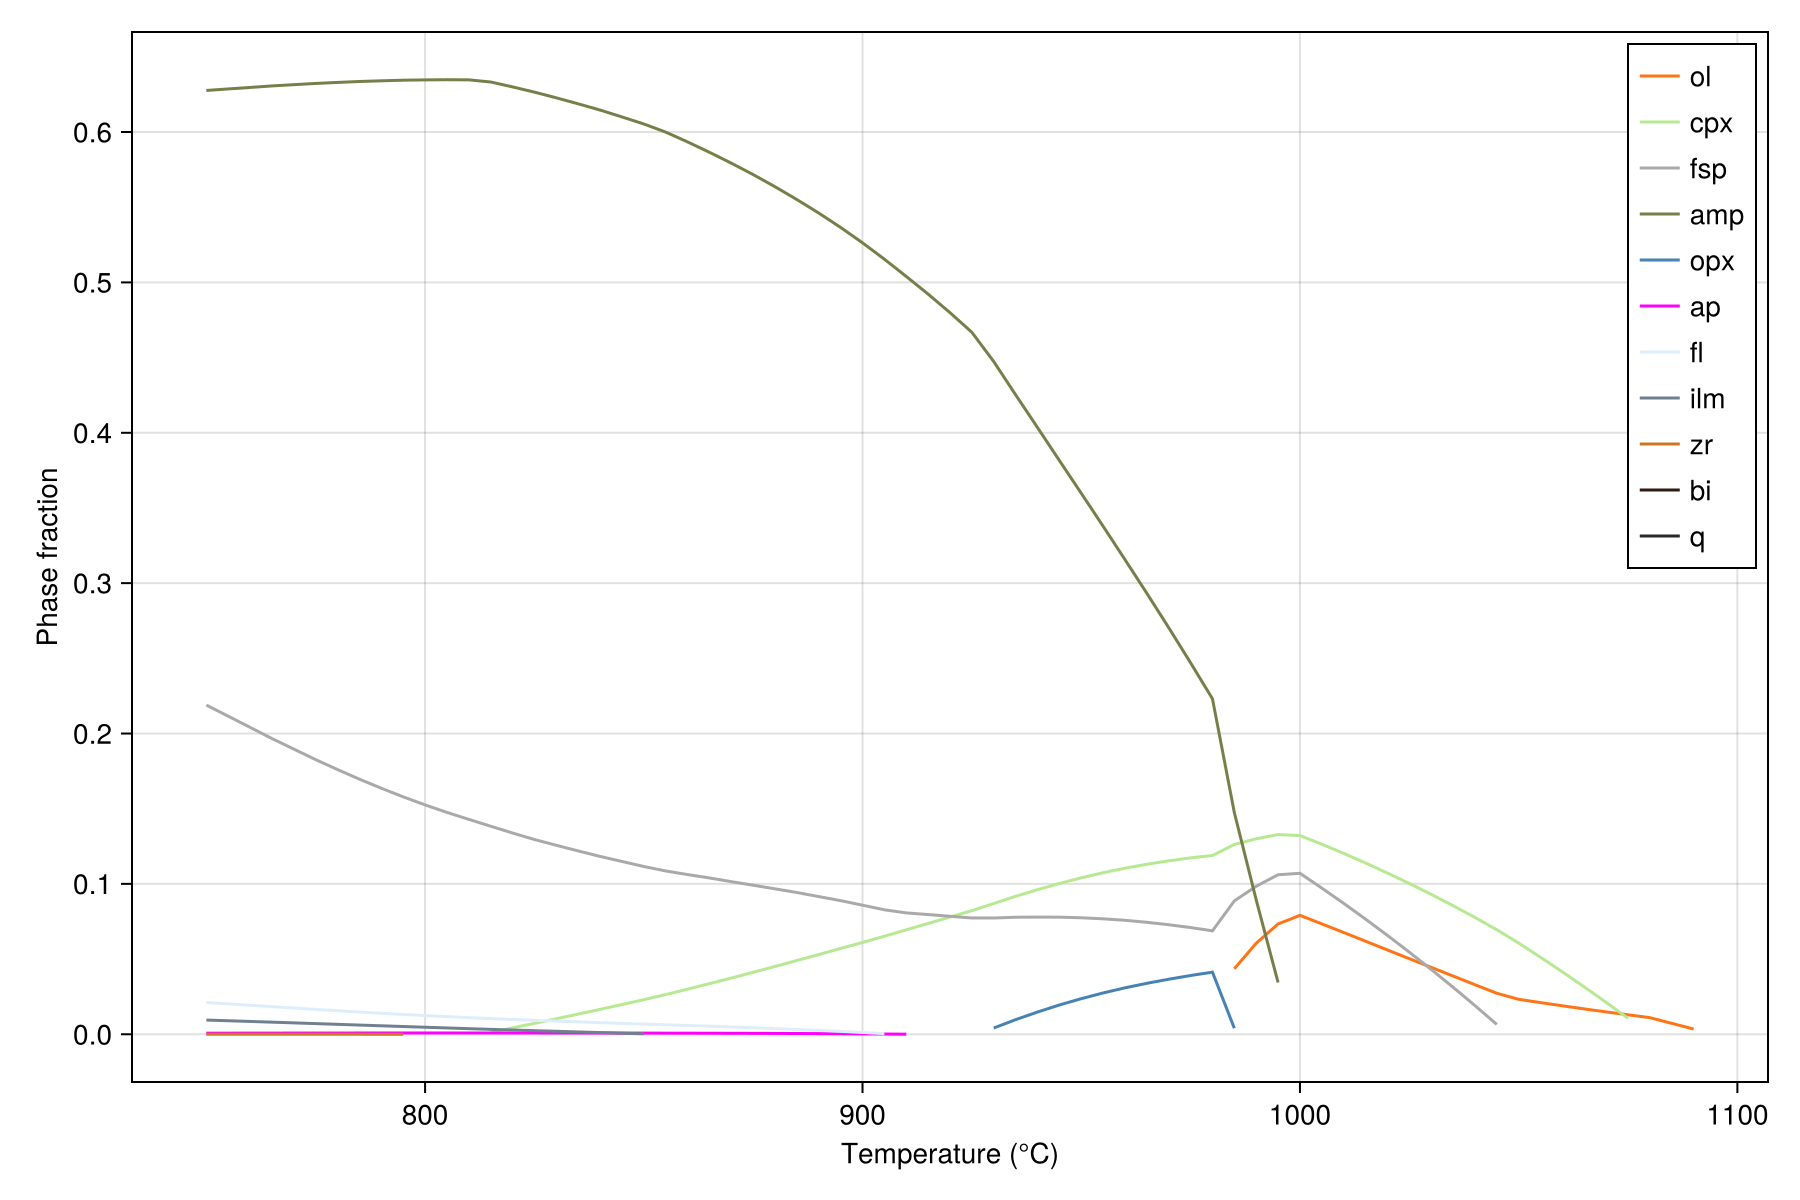

In [111]:
""" Simple line plot of selected phase fractions """

#phases_to_plot = ["ol", "cpx", "amp", "fsp", "opx", "g", "ap", "zr"]
# Get all unique phase names from phasefracs
phases_to_plot = unique([String(k) for d in phasefracs for k in keys(d)])
# Delete "liq"
phases_to_plot = setdiff(phases_to_plot, ["liq"])
fig = LSMPlotting.phaselineplot(phasefracs[1:np-10], phases_to_plot, T_C[1:np-10], "Temperature (°C)") # Excluding some later steps as very high phase fractions might occur

#save("Figures/", fig)

fig

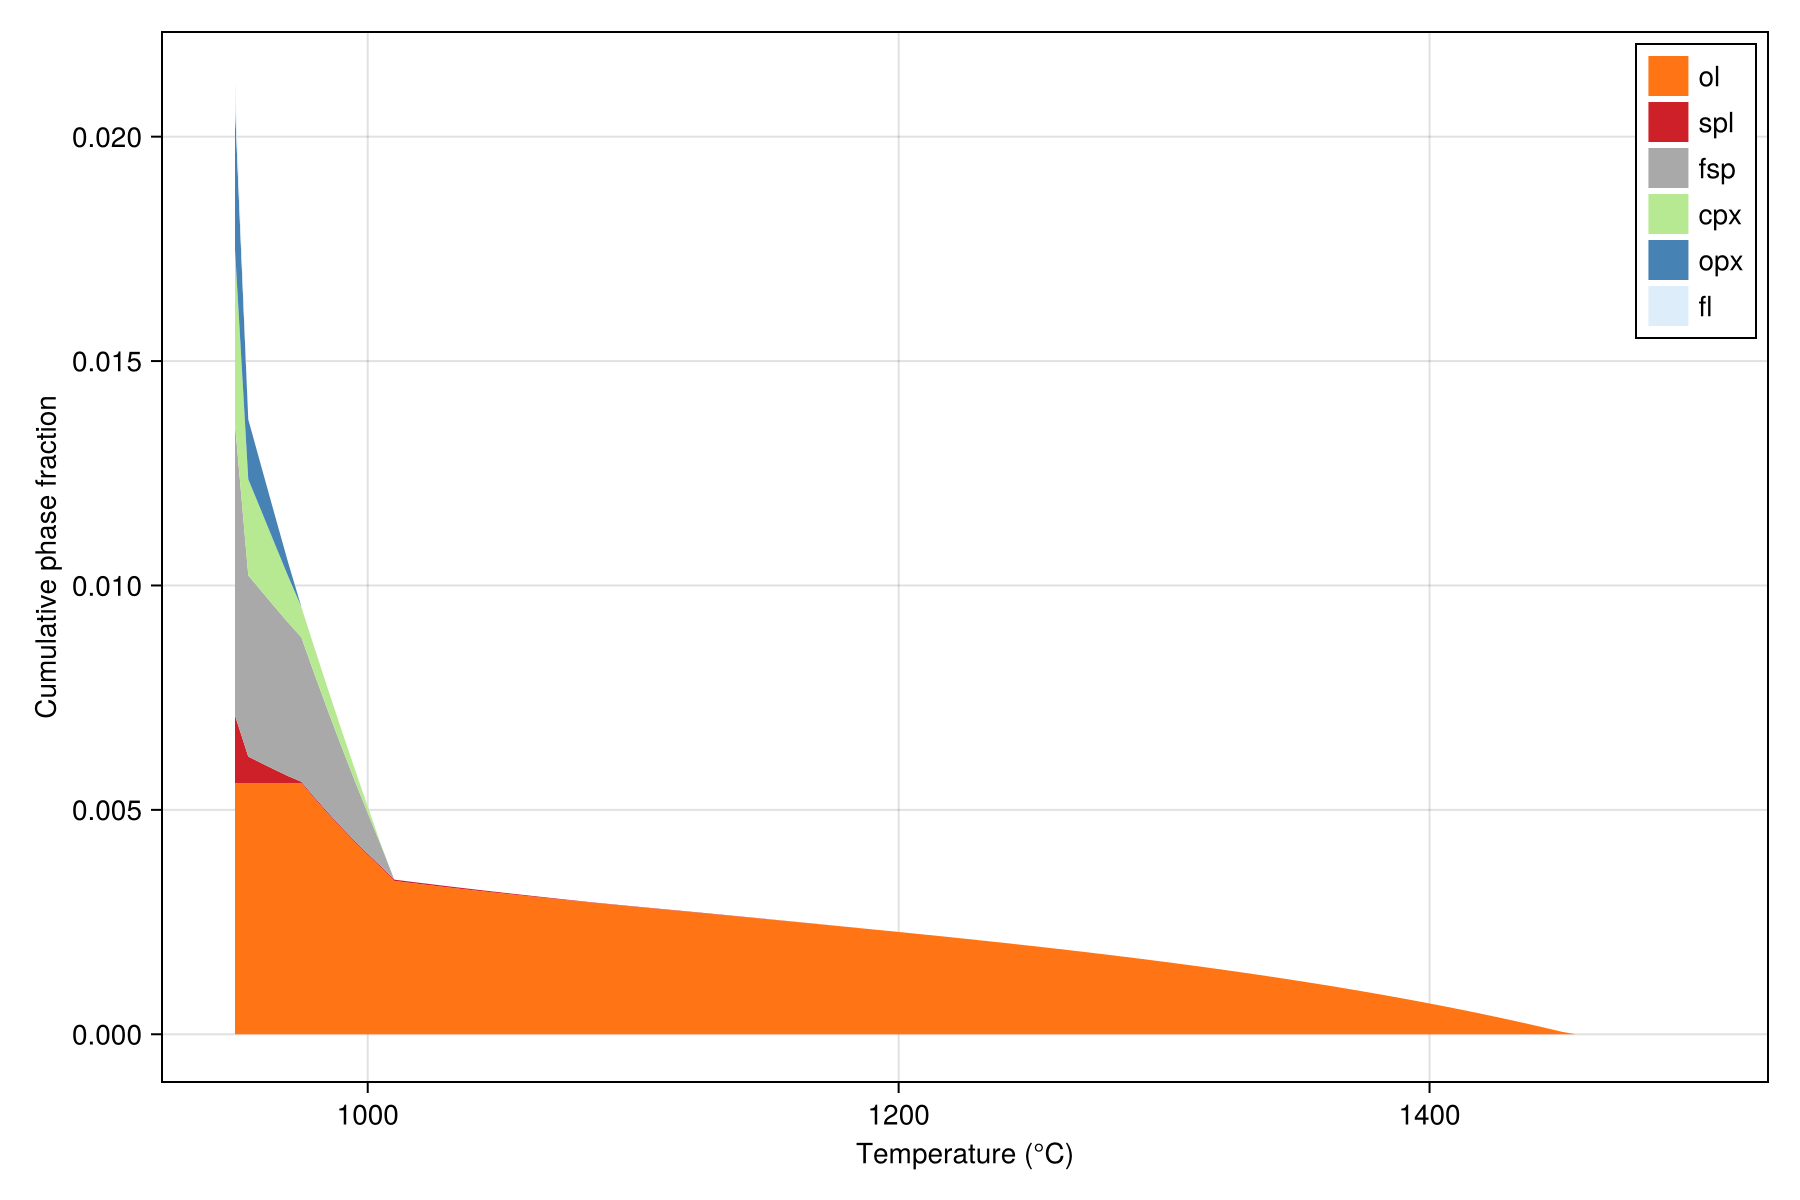

In [71]:
""" Cumulative phase plot for FCX ONLY """

fig = LSMPlotting.cumulphaseplot(phasefracs[1:np-5], T_C[1:np-5], "Temperature (°C)")

fig

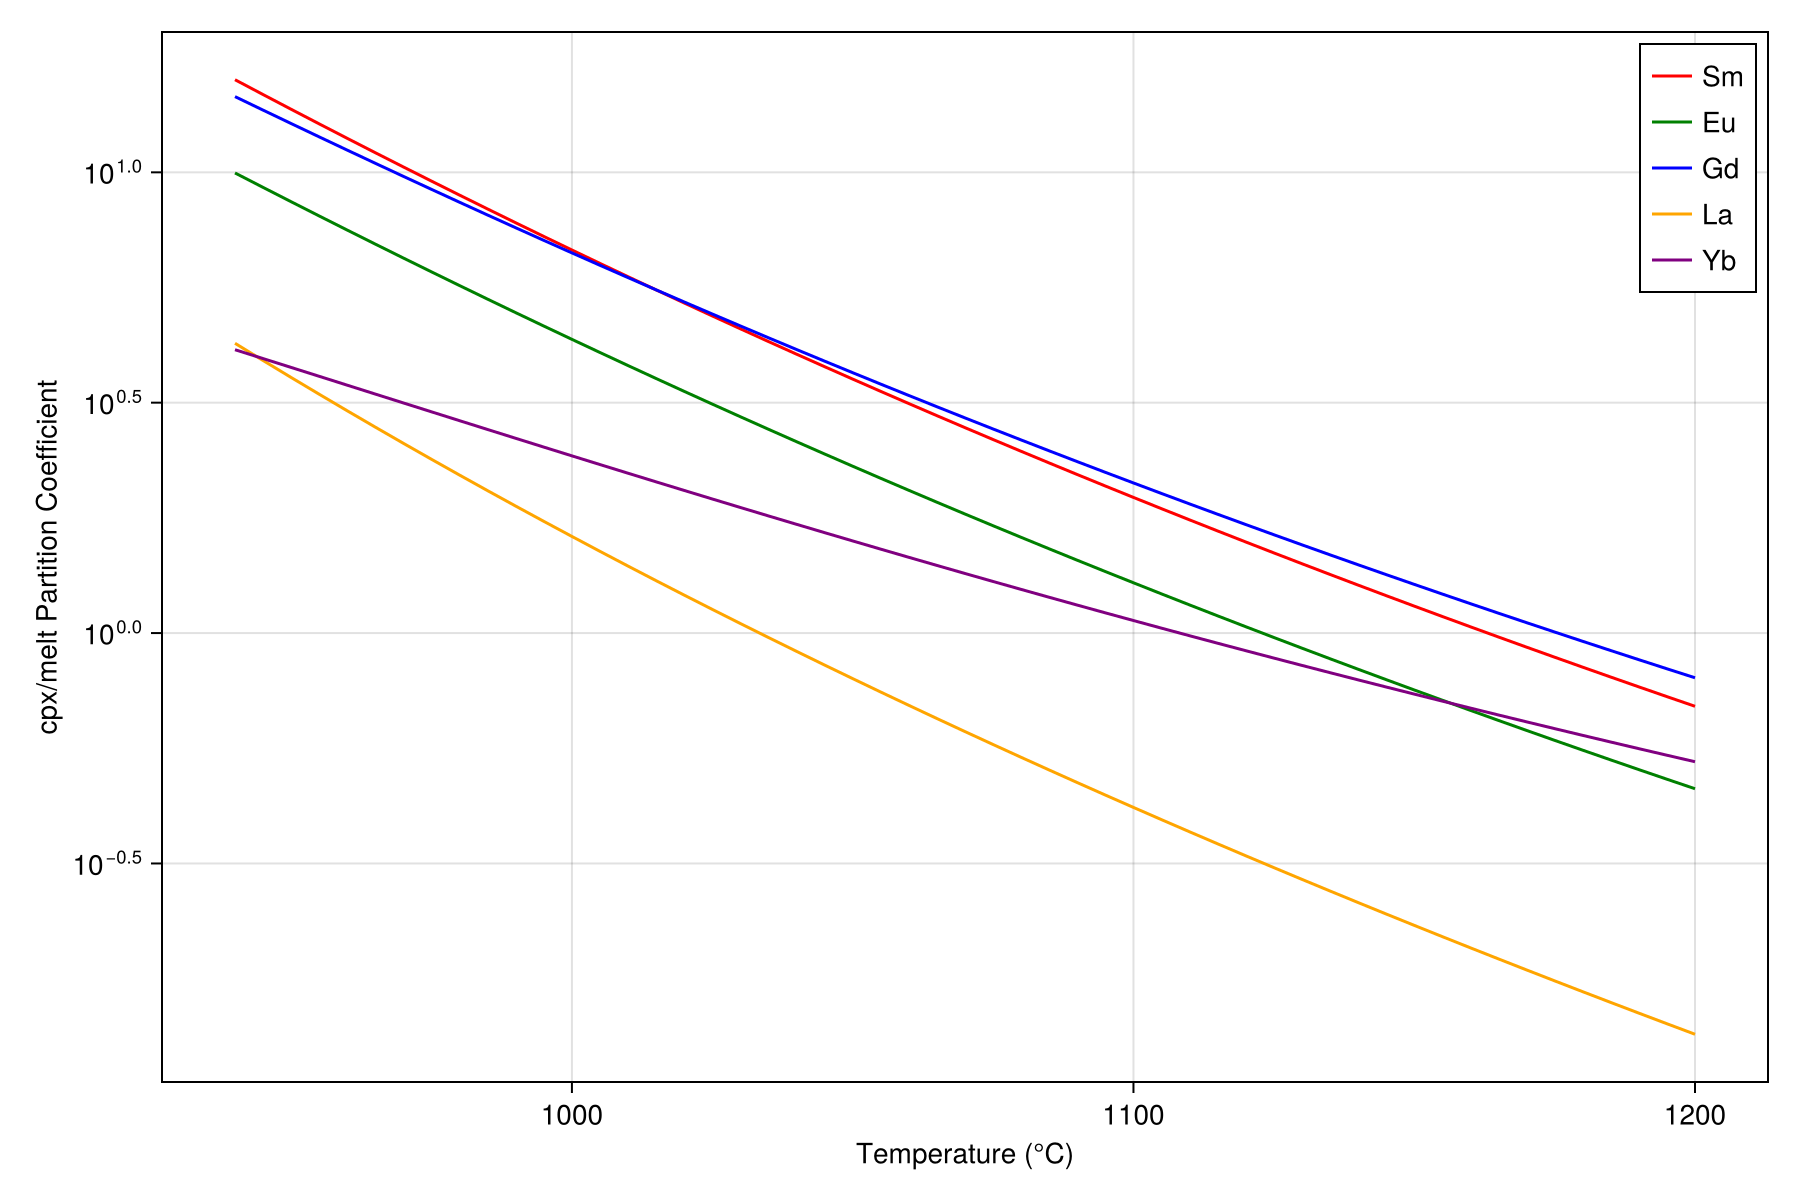

In [121]:
""" Partition coefficients for a selected phase and selected elements """

phase = "cpx" # Select "bulk" for bulk partition coefficients, or any phase in the output
elements = [:Sm, :Eu, :Gd, :La, :Yb]


fig = CairoMakie.Figure(size=(900, 600))
ax = Axis(fig[1, 1], xlabel="Temperature (°C)", ylabel="$(phase)/melt Partition Coefficient", yscale=log10)

phase_indices = [i for i in 1:np if haskey(Out_Ds[i], phase)]

phase_Kds = [Out_Ds[i][phase] for i in phase_indices]
kd_series = Dict(el => [phase_Kds[i][el] for i in eachindex(phase_indices)] for el in elements)

valid_indices = [i for i in eachindex(phase_indices) if all(kd_series[el][i] != 0 for el in elements)]

colors = [:red, :green, :blue, :orange, :purple, :brown]
for (j, el) in enumerate(elements)
    lines!(ax, T_C[valid_indices], kd_series[el][valid_indices],
        color=colors[mod1(j, length(colors))], label=String(el))
end

axislegend(ax)
fig

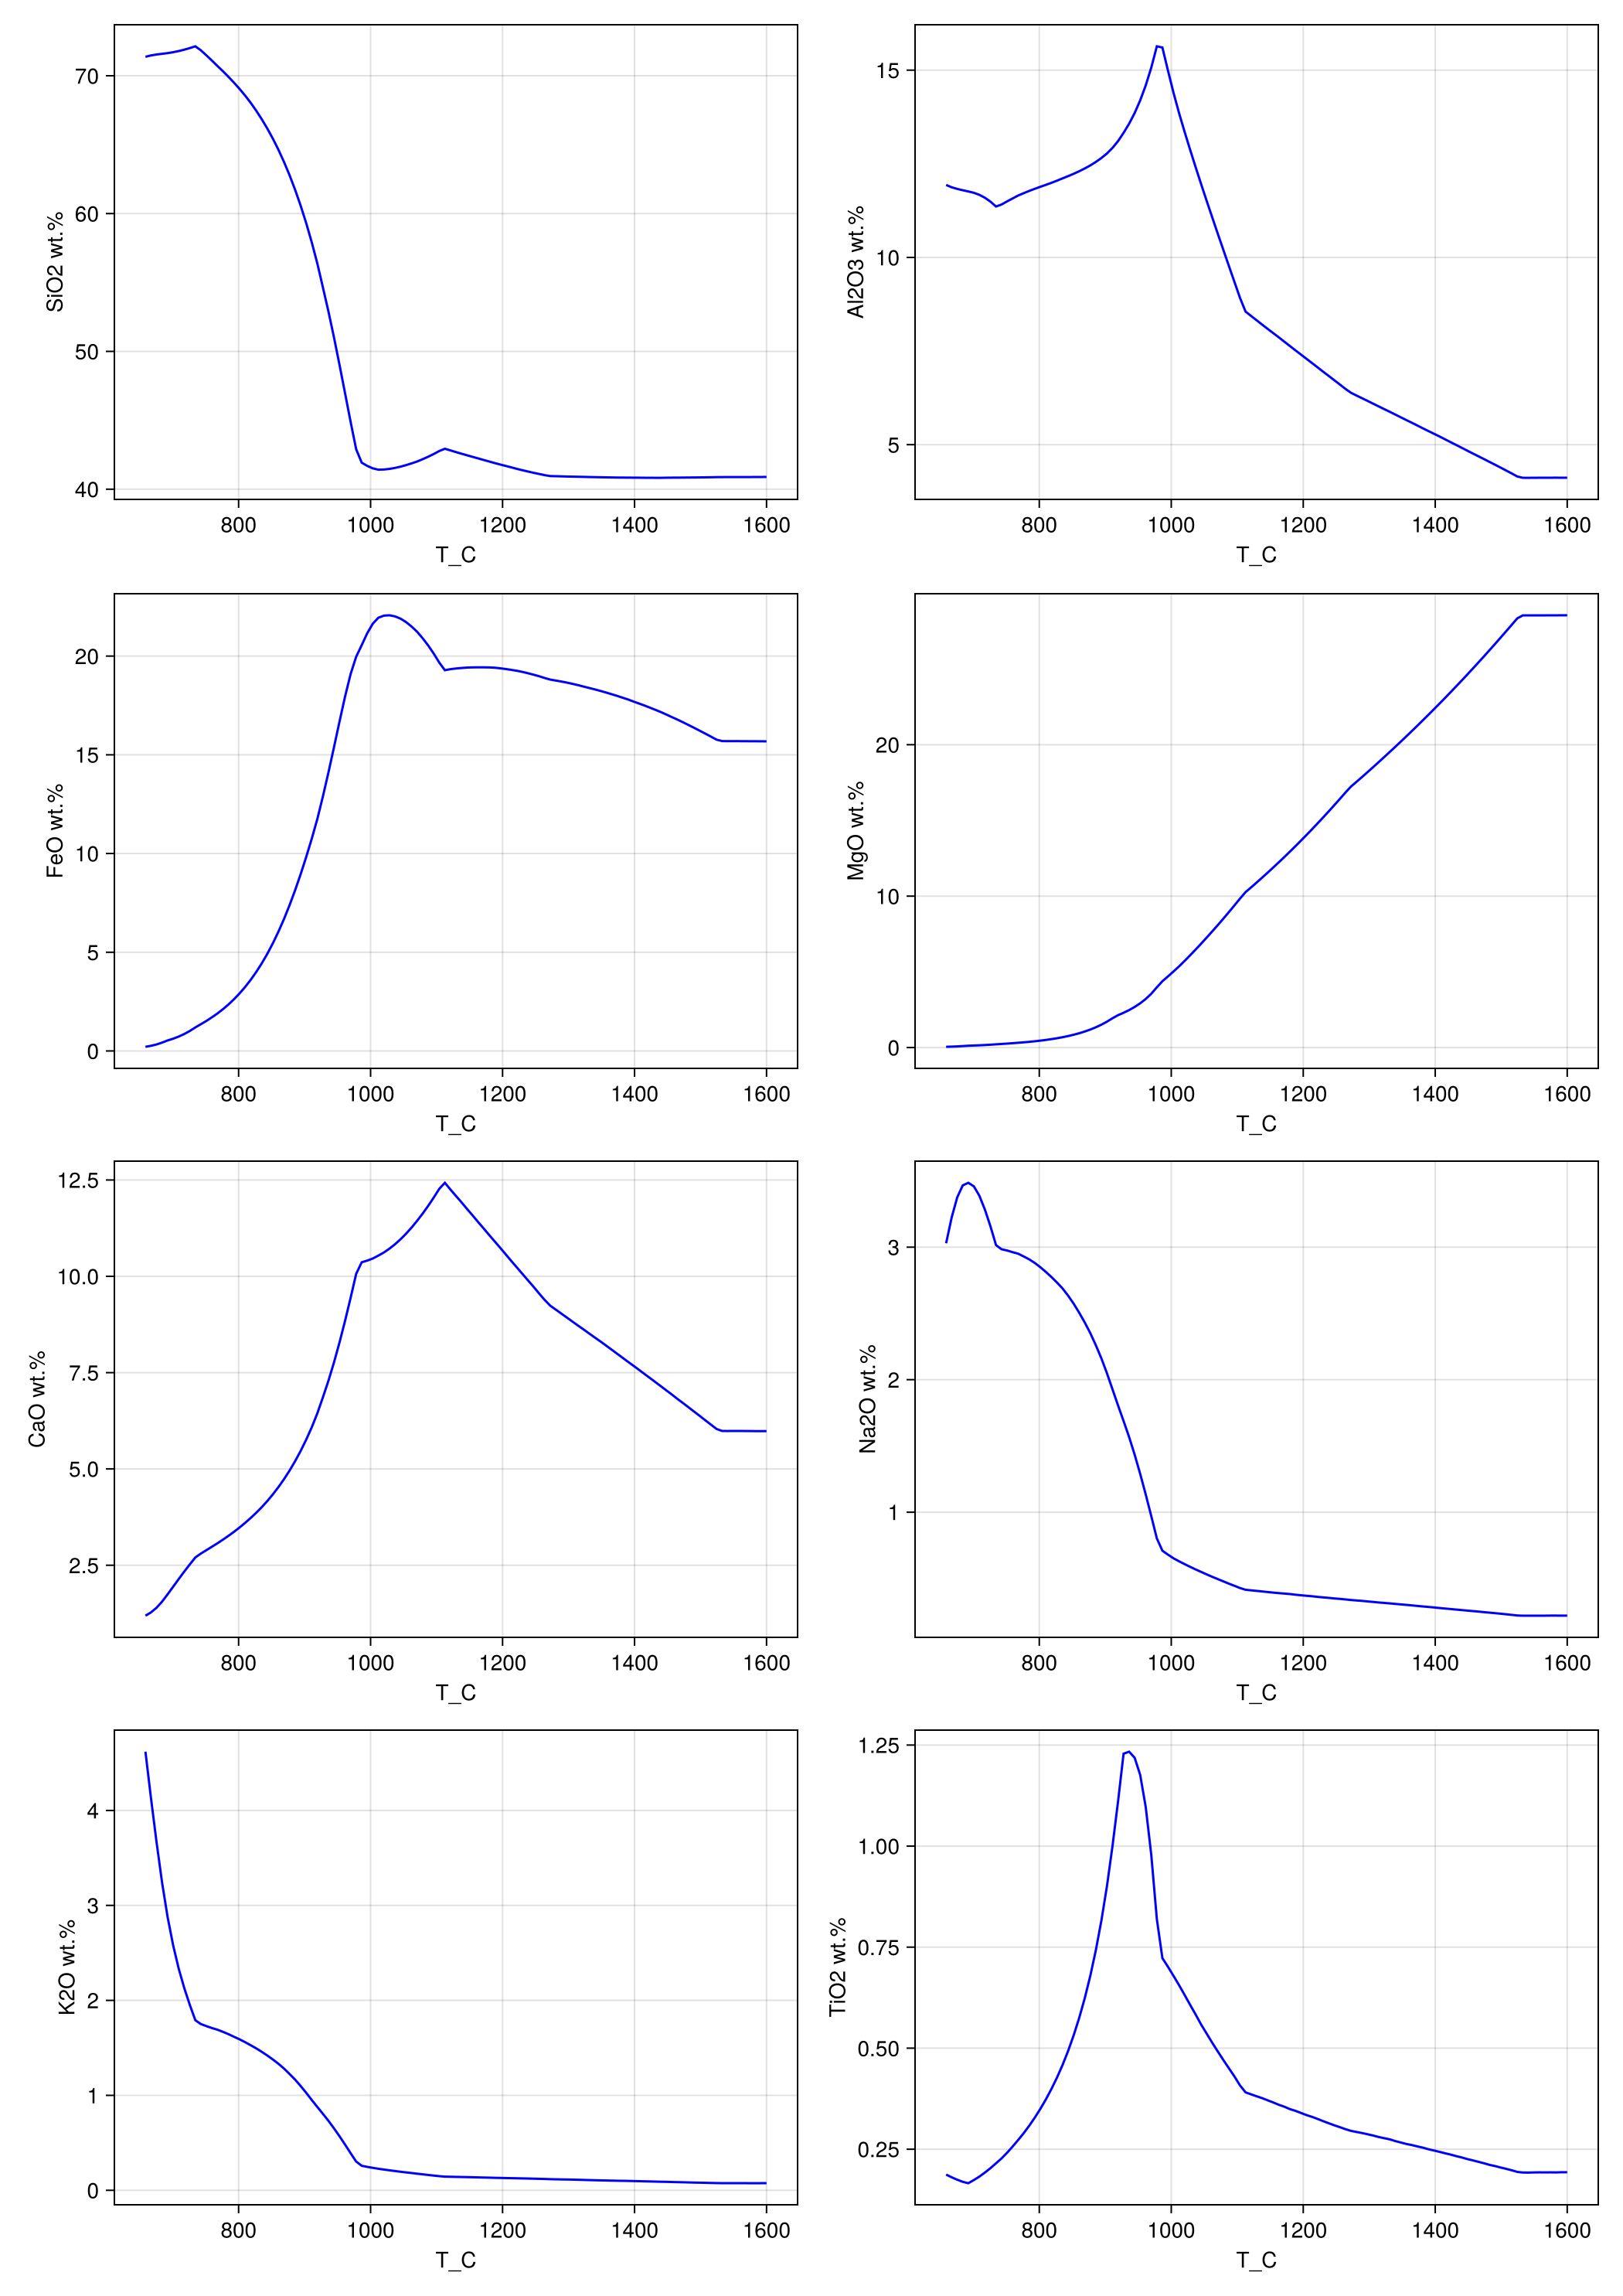

In [133]:
""" Liquid lines of descent """


x_value = "T_C" # Select oxide for x-axis, e.g. "SiO2", "MgO", "FeO", "H2O" or set to any desired parameter such as temperature 
major_els = ["SiO2", "Al2O3", "FeO", "MgO", "CaO", "Na2O", "K2O", "TiO2"] # Major elements to plot

# Figure 1: Major element oxides
# Make figure A4 sized (*3 scaled)
fig = CairoMakie.Figure(size=(210*5, 297*5))

# Out_XY.oxides contains oxide names while Out_XY.bulk_M_wt contains the corresponding melt compositions in wt.%
ncols = 2

for (i, el) in enumerate(major_els)
    row = cld(i, ncols)
    col = isodd(i) ? 1 : 2

    ax = Axis(fig[row, col], xlabel="$(x_value)", ylabel="$(el) wt.%")
    el_index = findfirst(==(el), Out_XY[1].oxides)
    el_values = [Out_XY[j].bulk_M_wt[el_index] for j in 1:np] .* 100.0
    #x_index = findfirst(==(x_value), Out_XY[1].oxides)
    """ Uncomment below if T_C is not used as x-axis """
    #x_vals = [Out_XY[j].bulk_M_wt[x_index] for j in 1:np] .* 100.0
    t_vals = [Out_XY[j].T_C for j in 1:np]
    lines!(ax, t_vals[1:np], el_values[1:np], color=:blue)
end

fig

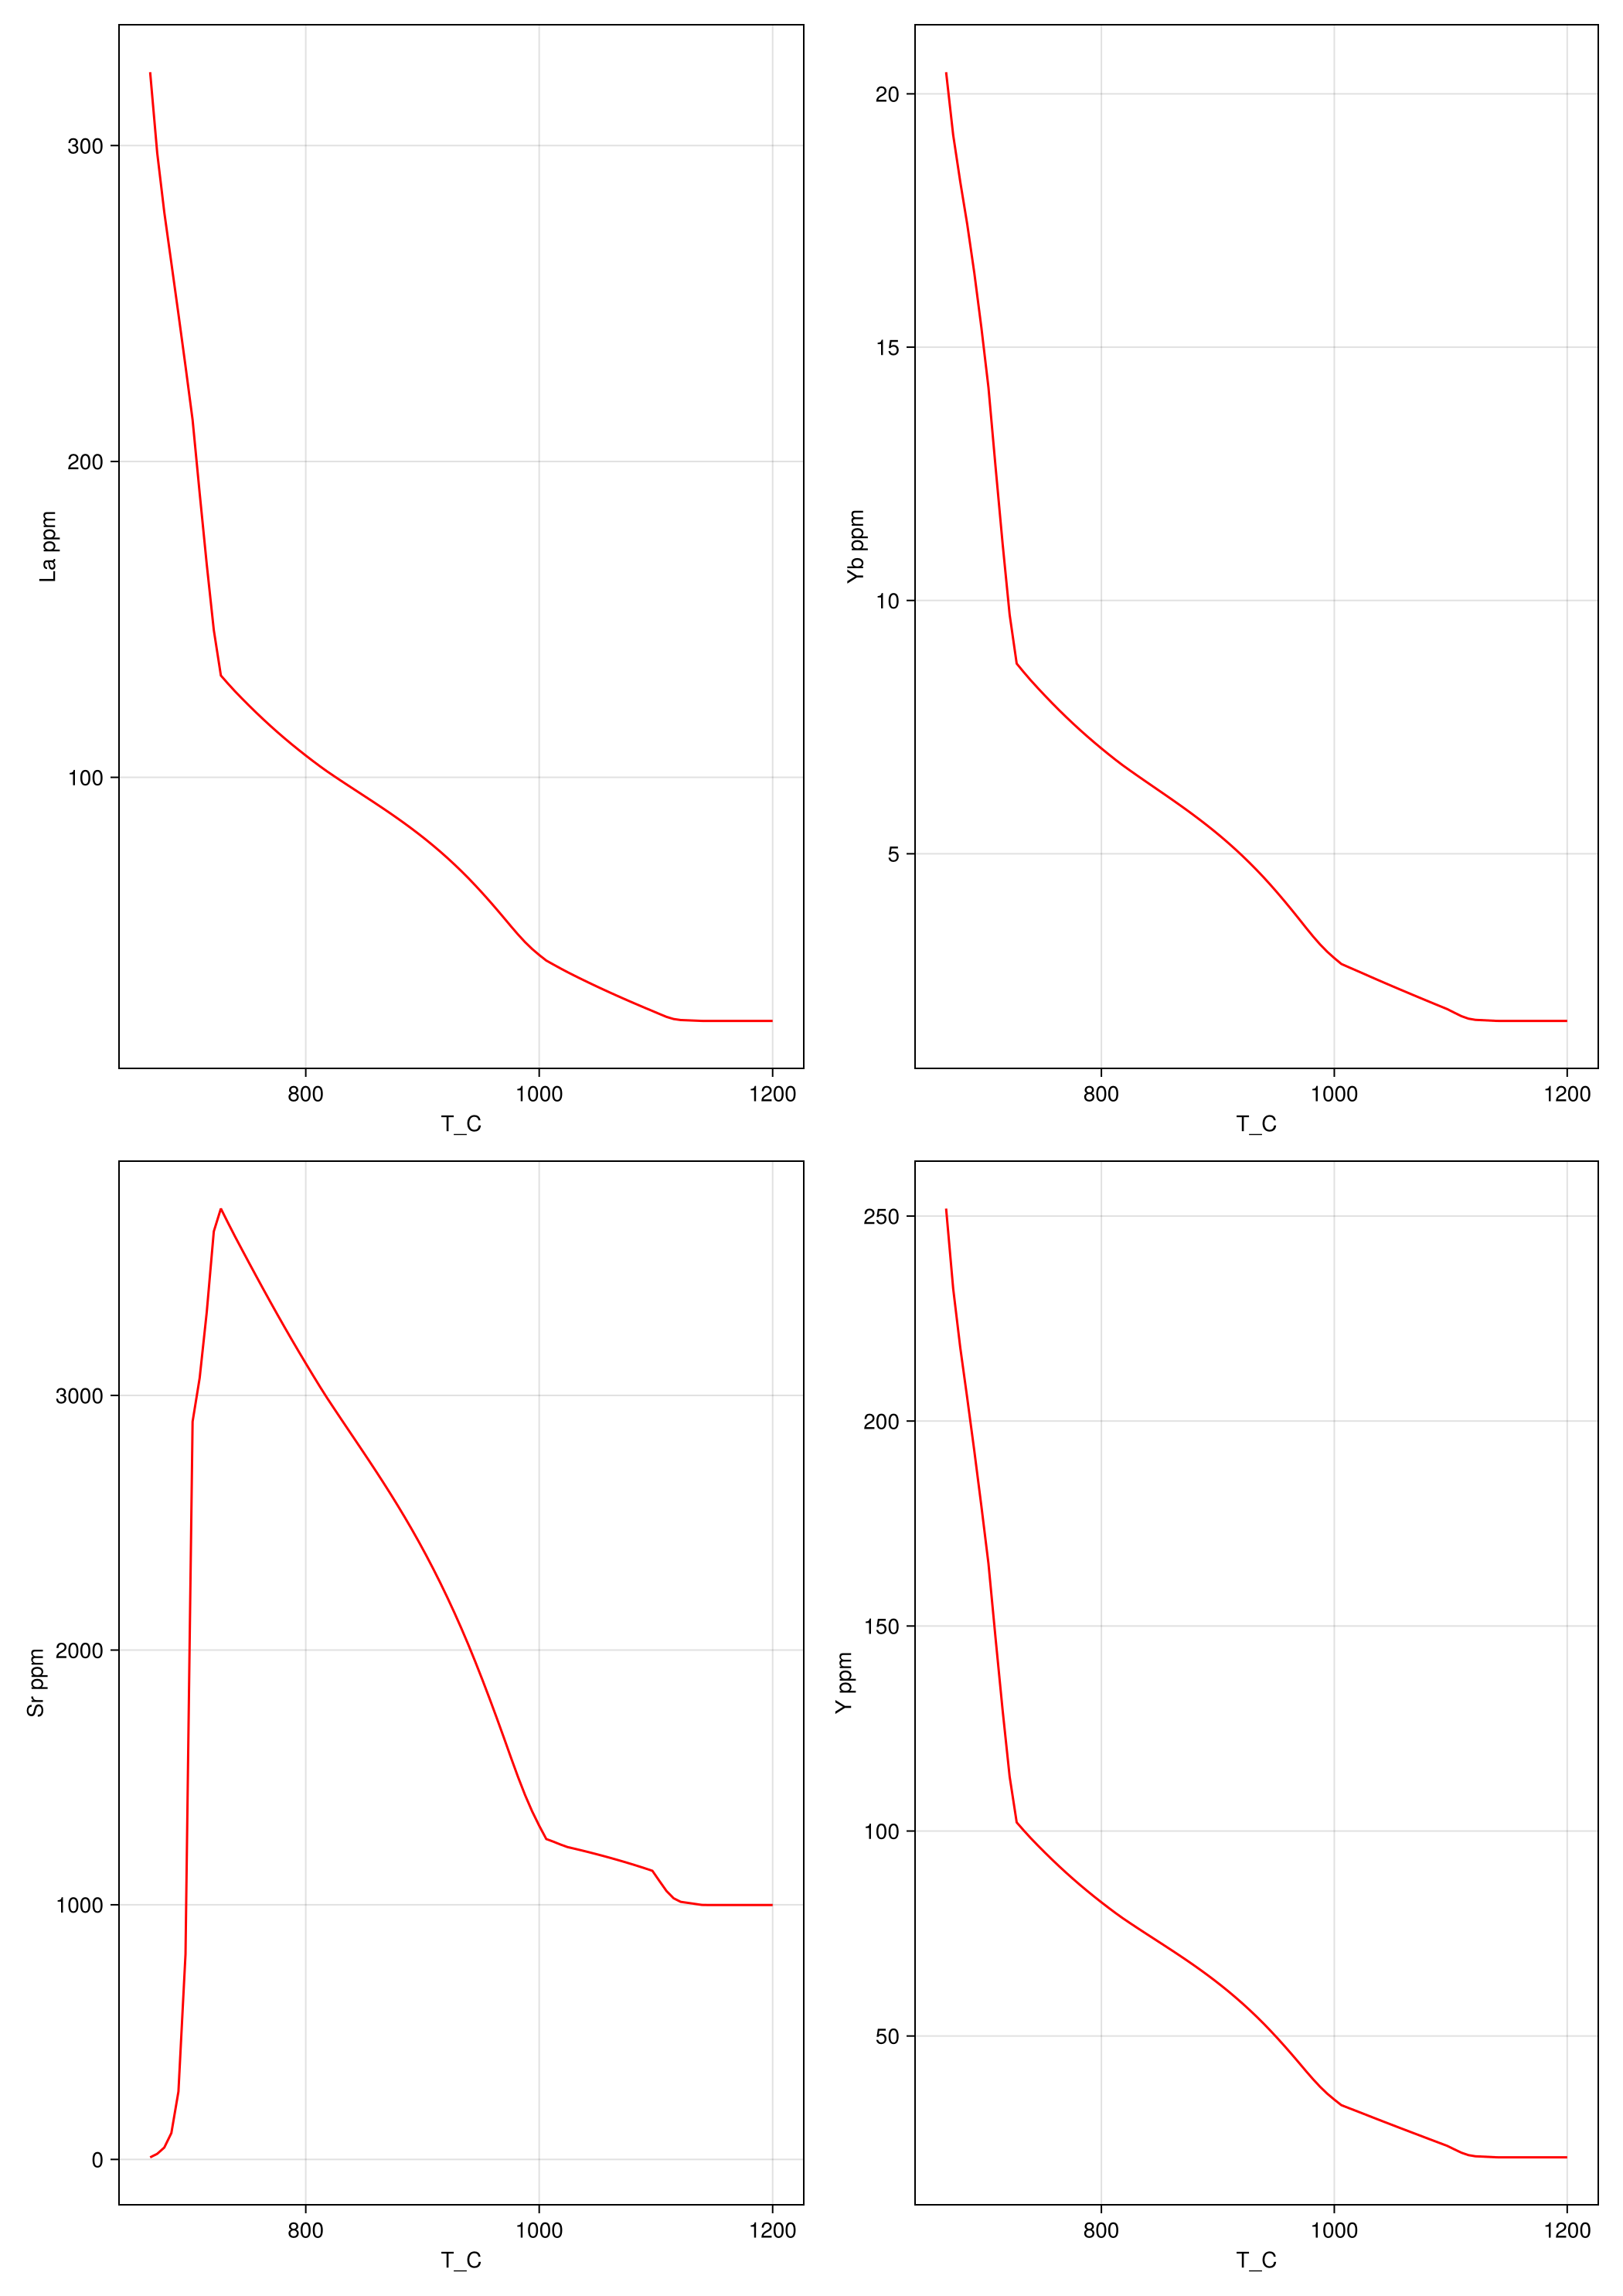

In [53]:
# Figure 2: Trace elements
fig = CairoMakie.Figure(size=(210*5, 297*5))
phase = "liq"
tr_els = [:La, :Yb, :Sr, :Y]



# Out_TE contains dicts of dicts of TE concentrations. Each outer dict corresponds to a step, and has keys of phase names. Each inner dict has keys of element symbols and values of TE concentrations in ppm.
# Select "liq" phase for melt concentrations

ncols = 2

for (i, el) in enumerate(tr_els)
    row = cld(i, ncols)
    col = isodd(i) ? 1 : 2

    ax = Axis(fig[row, col], xlabel="$(x_value)", ylabel="$(el) ppm")
    el_values = [Out_TE[j]["liq"][el] for j in 1:np]
    x_index = findfirst(==(x_value), Out_XY[1].oxides)
    """ Uncomment below if T_C is not used as x-axis """
    #x_vals = [Out_XY[j].bulk_M_wt[x_index] for j in 1:np] .* 100.0
    t_vals = [Out_XY[j].T_C for j in 1:np]
    lines!(ax, t_vals[1:np], el_values[1:np], color=:red)
end

fig

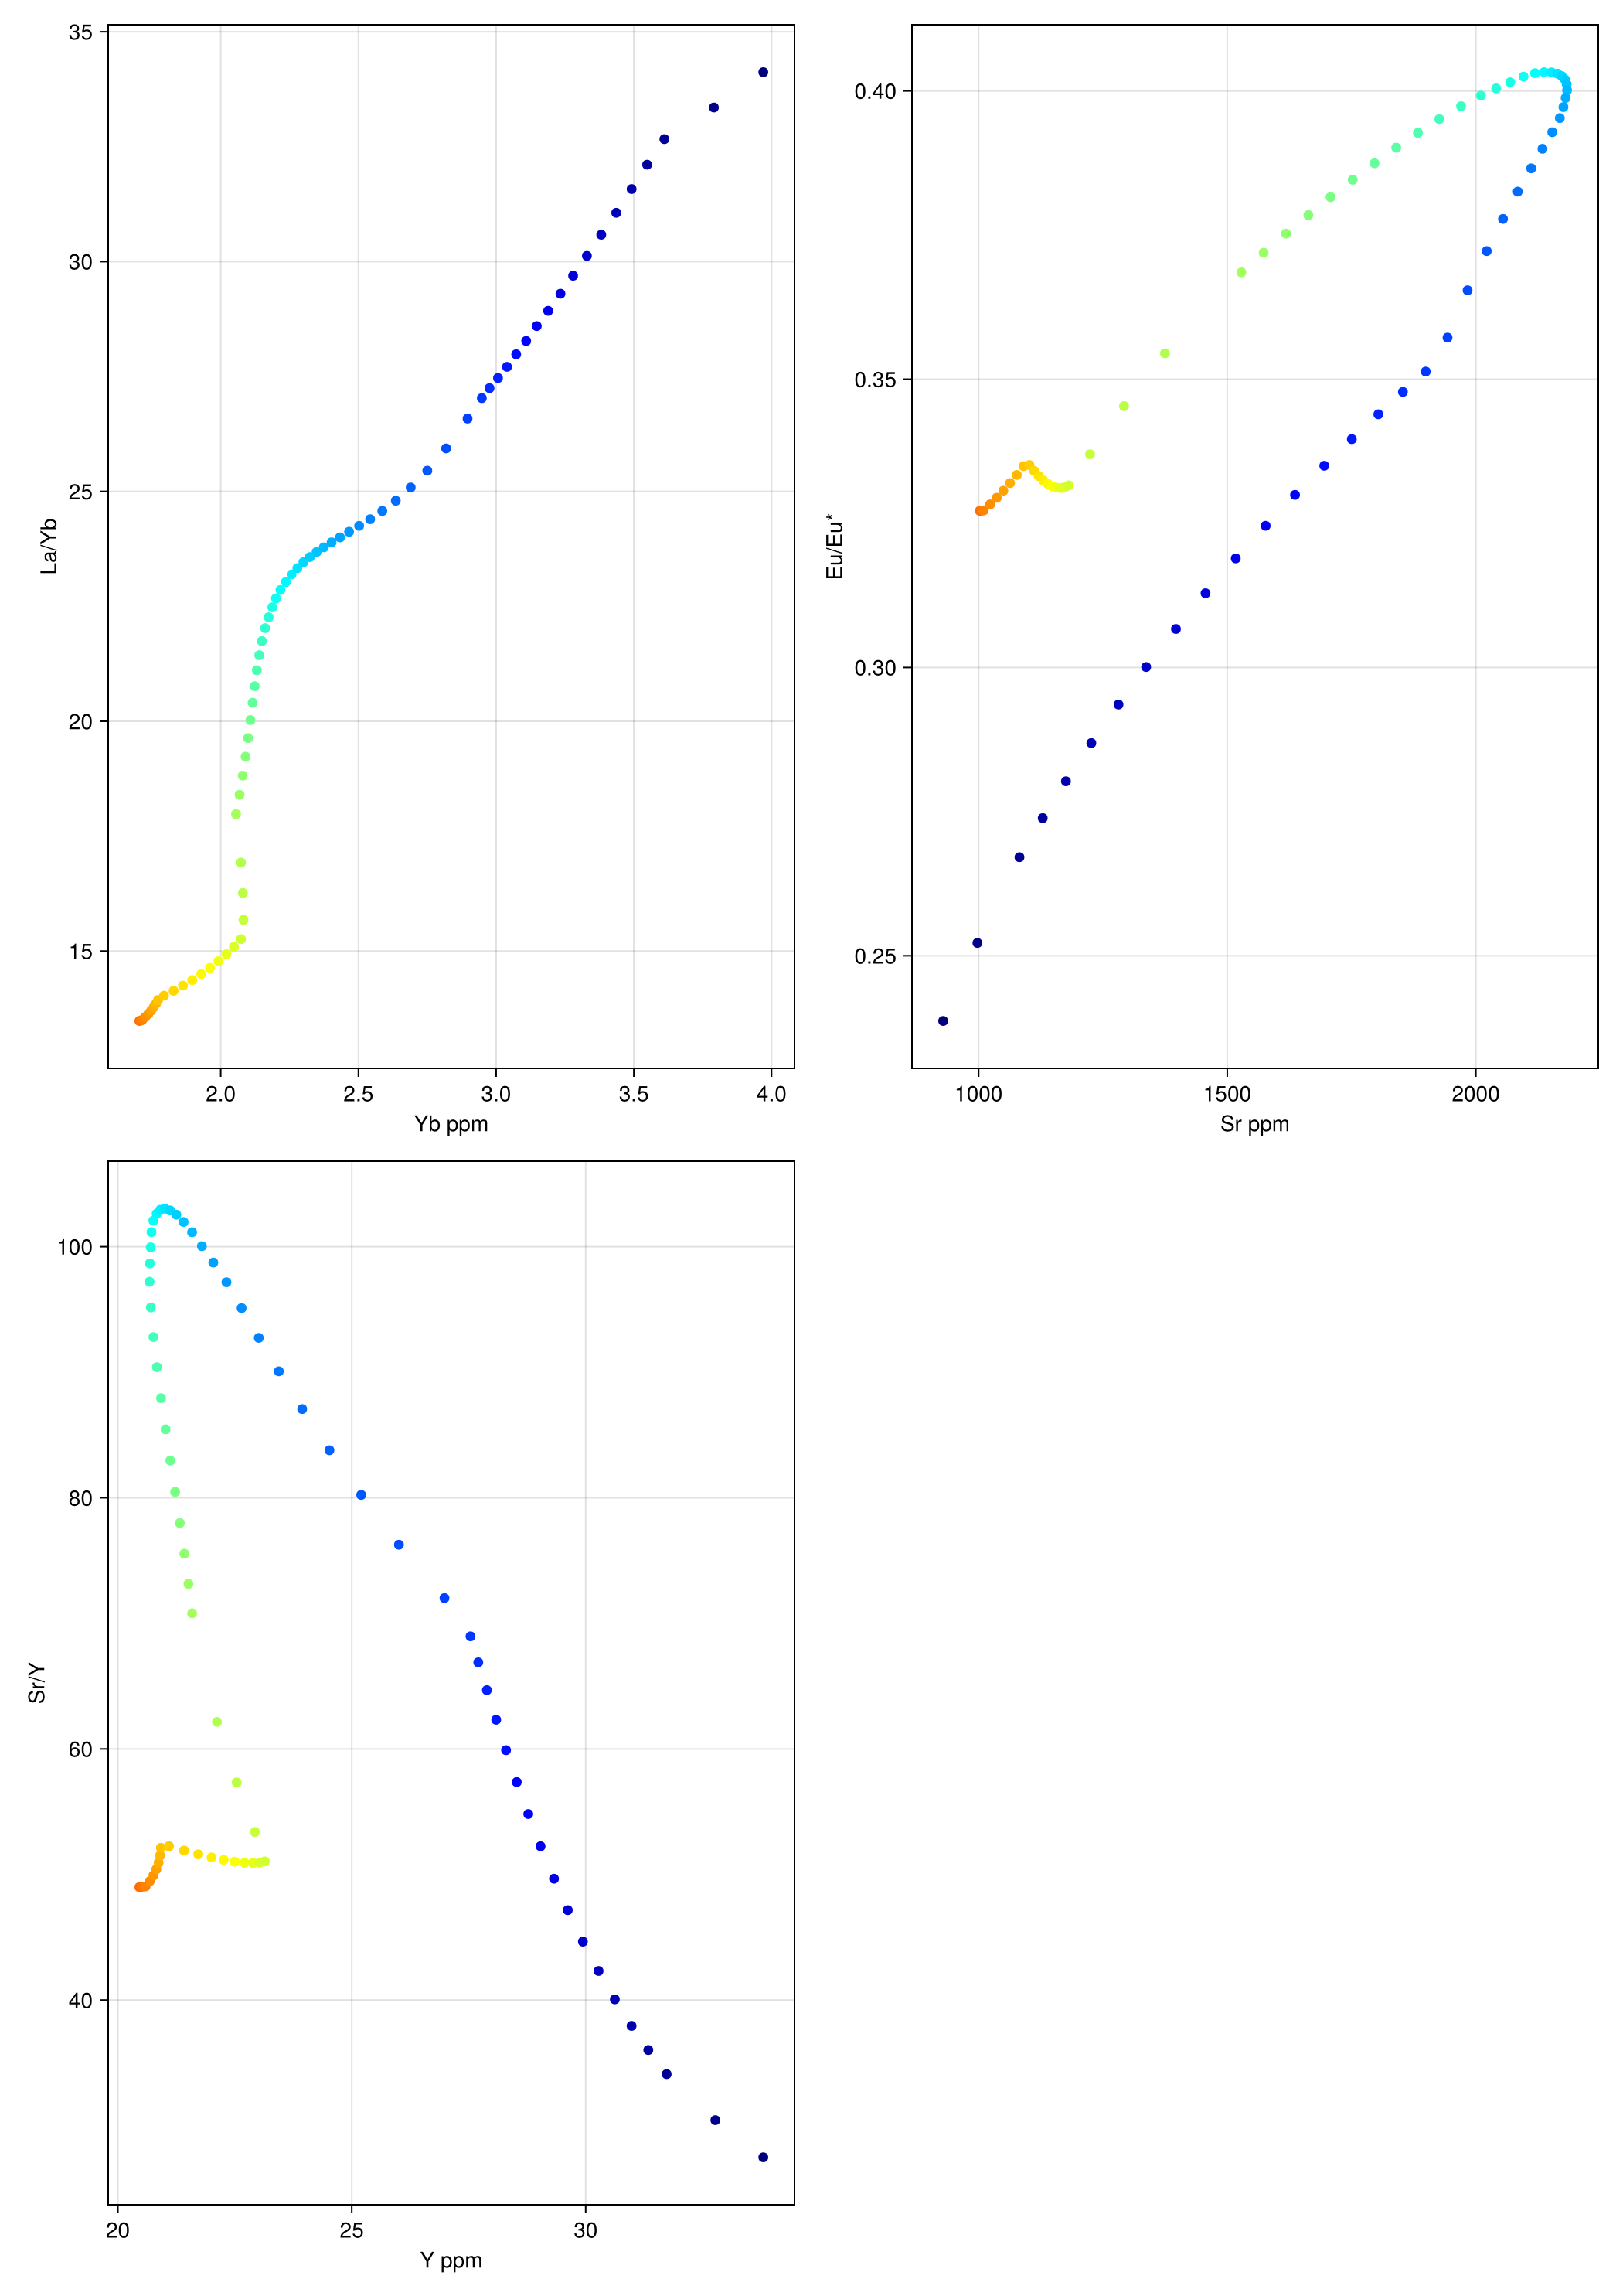

In [122]:
# Plot La/Yb vs Yb, Eu/Eu* = Eu/√(Sm*Gd) vs Sr and Sr/Y vs Y 

fig = CairoMakie.Figure(size=(210*5, 297*5))
subplots = 3
t_vals = [Out_XY[j].T_C for j in 1:np-5]
# Subplot 1: La/Yb vs Yb
ax1 = Axis(fig[1, 1], xlabel="Yb ppm", ylabel="La/Yb")
y_vals = [Out_TE[j]["liq"][:La] / Out_TE[j]["liq"][:Yb] for j in 1:np-5]
x_vals = [Out_TE[j]["liq"][:Yb] for j in 1:np-5]
scatter!(ax1, x_vals, y_vals, color=t_vals, colormap=:jet)
# Subplot 2: Eu/Eu* vs Sr
ax2 = Axis(fig[1, 2], xlabel="Sr ppm", ylabel="Eu/Eu*")
y_vals = [Out_TE[j]["liq"][:Eu] / sqrt(Out_TE[j]["liq"][:Sm] * Out_TE[j]["liq"][:Gd]) for j in 1:np-5]
x_vals = [Out_TE[j]["liq"][:Sr] for j in 1:np-5]
scatter!(ax2, x_vals, y_vals, color=t_vals, colormap=:jet)
# Subplot 3: Sr/Y vs Y
ax3 = Axis(fig[2, 1], xlabel="Y ppm", ylabel="Sr/Y")
y_vals = [Out_TE[j]["liq"][:Sr] / Out_TE[j]["liq"][:Y] for j in 1:np-5]
x_vals = [Out_TE[j]["liq"][:Y] for j in 1:np-5]
scatter!(ax3, x_vals, y_vals, color=t_vals, colormap=:jet)

fig
